In [1]:
# This cell is only used to suppress some distracting output messages
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

In [22]:
from datetime import datetime
from pathlib import Path

import cartopy.crs as ccrs
import ewatercycle.forcing
import ewatercycle.models
import ewatercycle.parameter_sets
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from cartopy import feature as cfeature
from matplotlib.colors import LogNorm
from rich import print

In [ ]:
# Chatly_station_latitude = 42.34332908492399  # Amu Darya near Chatly
# Chatly_station_longitude = 59.627516175820965

Chatly_station_latitude = 42.34332908492399 - 0.5  # Amu Darya near Chatly
Chatly_station_longitude = (
    59.627516175820965 + 0.9
)  # Through trial and error, to get modelled discharge closer to observed

Kerki_station_latitude = 37.8396310038444  # Amu Darya near Kerki
Kerki_station_longitude = 65.23703868931334

# Tyumen_station_latitude = 44.01445789449254 # Syr Darya near Tyumen, google maps
# Tyumen_station_longitude = 67.02866313732494

# Tyumen_station_latitude = 44.05 # Syr Darya near Tyumen, GRDC coords
# Tyumen_station_longitude = 67.05

Tyumen_station_latitude = 44.05 - 0.1  # Syr Darya near Tyumen, through trial and error
Tyumen_station_longitude = 67.05

Kazalinsk_station_latitude = (45.739988222442456,)  # Syr Darya near Kazalinsk
Kazalinsk_station_longitude = 62.115993992559744

In [4]:
# set start and end date of the experiment, overwrites .ini settings
experiment_start_date = "1959-01-01T00:00:00Z"
# experiment_end_date = "1992-12-31T00:00:00Z" #was 1995-12-31T00:00:00Z, shorter for testing
# experiment_end_date = "1990-02-28T00:00:00Z" #2 months, for testing
experiment_end_date = "1959-12-31T00:00:00Z"  # 2 months, for testing

In [5]:
pcr_glob_directory = Path("/data/shared/parameter-sets/pcrglobwb_global")  # GlobalOption uit .ini

prepared_PCRGlob_forcing = (
    Path(
        "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/forcing_5570"
    )
    / "AralSeaBasin"
    / "pcrglobwb"
    / "work/diagnostic/script"
)  ##MeteoOptions uit .ini

prepared_PCRGlob_forcing_CMIP = (
    Path(
        "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Comparison/forcing_CMIP_5570"
    )
    / "AralSeaBasin"
    / "CMIP6"
    / "historic"
    / "PCRGlobWB"
    / "work/diagnostic/script"
)  ##MeteoOptions uit .ini

In [ ]:
parameter_set_2rivers = ewatercycle.parameter_sets.ParameterSet(
    name="custom_parameter_set",
    directory=pcr_glob_directory,
    config=Path.cwd() / "Reference_05min_2rivers.ini",
    target_model="pcrglobwb",
    supported_model_versions={"setters"},
)

In [ ]:
forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
    directory=prepared_PCRGlob_forcing,
)


print(forcing)

PCRGlobWBForcing(
    start_time='1955-01-01T00:00:00Z',
    end_time='1970-12-31T00:00:00Z',
    directory=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in
_progress/Test_Aral/forcing_5570/AralSeaBasin/pcrglobwb/work/diagnostic/script'),
    shape=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_pro
gress/Test_Aral/forcing_5570/AralSeaBasin/pcrglobwb/work/diagnostic/script/AralSeaBasin.shp'),
    filenames={},
    precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1955-1970_AralSeaBasin.nc',
    temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_1955-1970_AralSeaBasin.nc'
)

In [ ]:
reference = ewatercycle.models.PCRGlobWB(parameter_set=parameter_set_2rivers, forcing=forcing)

print(reference)

PCRGlobWB(
    parameter_set=ParameterSet(
        name='custom_parameter_set',
        directory=PosixPath('/data/shared/parameter-sets/pcrglobwb_global'),
        config=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_i
n_progress/model_runs/pcrglobwb/test_shapefile/Reference_05min_agri.ini'),
        doi='N/A',
        target_model='pcrglobwb',
        supported_model_versions={'setters'},
        downloader=None
    ),
    forcing=PCRGlobWBForcing(
        start_time='1955-01-01T00:00:00Z',
        end_time='1970-12-31T00:00:00Z',
        directory=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/wor
k_in_progress/Test_Aral/forcing_5570/AralSeaBasin/pcrglobwb/work/diagnostic/script'),
        shape=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in
_progress/Test_Aral/forcing_5570/AralSeaBasin/pcrglobwb/work/diagnostic/script/AralSeaBasin.shp'),
        filenames={},
        precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1955-1970_AralSeaBasin.nc',
        temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_1955-1970_AralSeaBasin.nc'
    )
)

In [9]:
reference_config, reference_dir = reference.setup(
    start_time=experiment_start_date, end_time=experiment_end_date, max_spinups_in_years=0
)
reference_config, reference_dir

('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_shapefile/pcrglobwb_20251217_123110/pcrglobwb_ewatercycle.ini',
 '/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_shapefile/pcrglobwb_20251217_123110')

In [10]:
print(reference.parameters)

refence_para = reference.parameters

# Convert ISO 8601 strings to datetime objects
start_time = datetime.strptime(experiment_start_date, "%Y-%m-%dT%H:%M:%SZ")
end_time = datetime.strptime(experiment_end_date, "%Y-%m-%dT%H:%M:%SZ")

# Calculate the number of days for the progression bar
delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")

dict_items([('start_time', '1959-01-01T00:00:00Z'), ('end_time', '1959-12-31T00:00:00Z'), ('routing_method', 
'accuTravelTime'), ('max_spinups_in_years', '0')])

Number of days to model: 364

In [11]:
reference.initialize(reference_config)

In [12]:
time = pd.date_range(reference.start_time_as_isostr, reference.end_time_as_isostr)
# timeseries = pd.DataFrame(
#     index=pd.Index(time, name="time"), columns=["reference", "experiment1", "experiment2"]
# )
# timeseries.head()

In [ ]:
Stations_timeseries = pd.DataFrame(
    index=pd.Index(time, name="time"), columns=["Chatly", "Kerki", "Tyumen", "Kazalinsk"]
)
Stations_timeseries.head()

Stations_timeseries_experiment_no_agri = Stations_timeseries.copy()
Stations_timeseries_experiment_RoutingWave = Stations_timeseries.copy();

In [16]:
from tqdm.notebook import tqdm

for _ in tqdm(range(number_of_days), desc="Running model"):
    reference.update()

    # Track discharge at station locations
    discharge_at_Chatly = reference.get_value_at_coords(
        "discharge", lat=[Chatly_station_latitude], lon=[Chatly_station_longitude]
    )
    discharge_at_Kerki = reference.get_value_at_coords(
        "discharge", lat=[Kerki_station_latitude], lon=[Kerki_station_longitude]
    )
    discharge_at_Tyumen = reference.get_value_at_coords(
        "discharge", lat=[Tyumen_station_latitude], lon=[Tyumen_station_longitude]
    )
    discharge_at_Kazalinsk = reference.get_value_at_coords(
        "discharge", lat=[Kazalinsk_station_latitude], lon=[Kazalinsk_station_longitude]
    )

    # Store values
    time = reference.time_as_isostr
    Stations_timeseries.loc[time, "Chatly"] = discharge_at_Chatly[0]
    Stations_timeseries.loc[time, "Kerki"] = discharge_at_Kerki[0]
    Stations_timeseries.loc[time, "Tyumen"] = discharge_at_Tyumen[0]
    Stations_timeseries.loc[time, "Kazalinsk"] = discharge_at_Kazalinsk[0]

print("Model run finished!")

Running model:   0%|          | 0/364 [00:00<?, ?it/s]

Model run finished!

In [17]:
Stations_timeseries.head()

,Chatly,Kerki,Tyumen,Kazalinsk,Dushanbe
time,,,,,
1959-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN
1959-01-02 00:00:00+00:00,47.660381,1158.444214,527.665344,657.164612,NaN
1959-01-03 00:00:00+00:00,1.118459,983.988037,555.355164,689.956177,NaN
1959-01-04 00:00:00+00:00,1.051283,2323.109619,964.1651,641.084656,NaN
1959-01-05 00:00:00+00:00,0.978919,97644.257812,24895.224609,573.513245,NaN


AttributeError: 'PCRGlobWB' object has no attribute '_bmi'

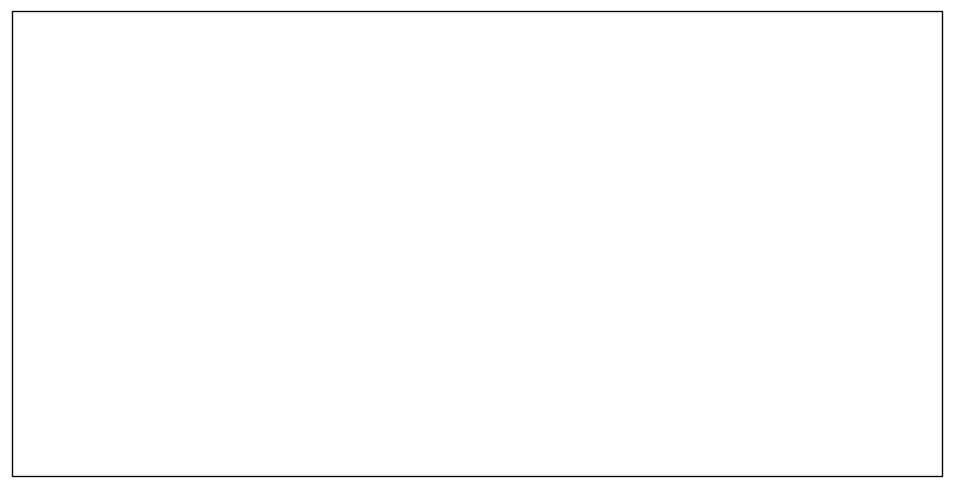

In [30]:
# Create figure
fig = plt.figure(figsize=(10, 8), dpi=120)
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

# Plot discharge with logarithmic scale
discharge = reference.get_value_as_xarray("discharge")
discharge.plot(
    ax=ax,
    cmap="GnBu",
    norm=LogNorm(vmin=1, vmax=20000),  # log scale
)

# Plot station locations
ax.scatter(Chatly_station_longitude + 1, Chatly_station_latitude - 0.5, s=25, c="r", label="Chatly")
ax.scatter(Kerki_station_longitude, Kerki_station_latitude, s=25, c="r", label="Kerki")
ax.scatter(Tyumen_station_longitude, Tyumen_station_latitude, s=25, c="r", label="Tyumen")
ax.scatter(Kazalinsk_station_longitude, Kazalinsk_station_latitude, s=25, c="r", label="Kazalinsk")

# Overlay coastlines, borders, lakes, ocean
ax.add_feature(cfeature.OCEAN, zorder=2)
ax.add_feature(cfeature.BORDERS, linestyle=":", zorder=2)
ax.add_feature(cfeature.LAKES, alpha=0.8, zorder=2)
ax.coastlines(zorder=3)

# Set extent (55E-80E, 33N-50N)
ax.set_extent([55, 80, 33, 50])

# Add legend
ax.legend(loc="upper right")

plt.show()

In [25]:
reference.finalize()

In [26]:
Stations_timeseries.to_csv("Reference_ERA5_5961.csv", index=True)

In [27]:
from ewatercycle.observation.grdc import get_grdc_data

grdc_chatly = get_grdc_data(
    2817100,
    "1900-01-01T00:00Z",
    "2001-01-01T00:00Z",
    data_home="/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/",
)

grdc_kerki = get_grdc_data(
    2617110,
    "1900-01-01T00:00Z",
    "2001-01-01T00:00Z",
    data_home="/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/",
)

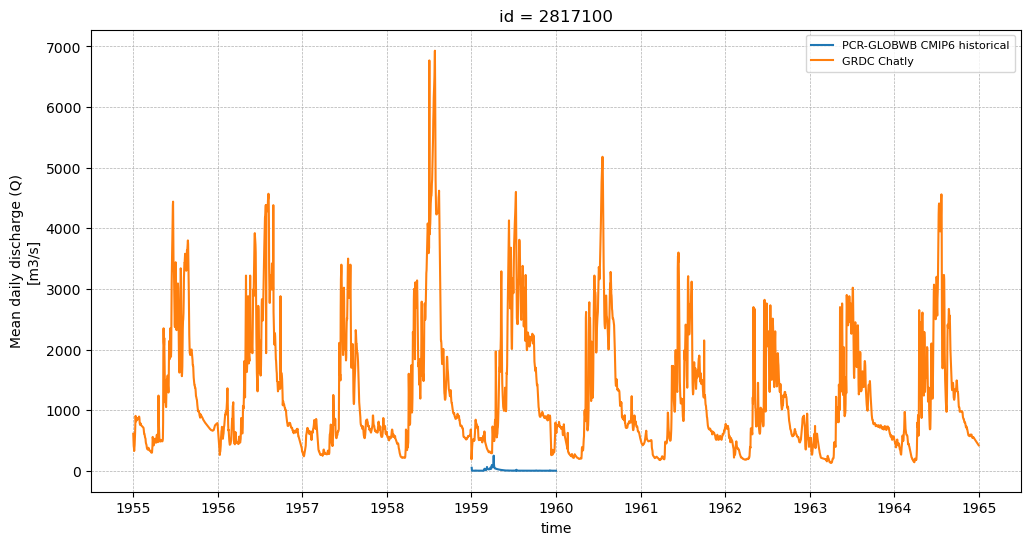

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(Stations_timeseries["Chatly"], label="PCR-GLOBWB CMIP6 historical")
grdc_chatly["streamflow"].sel(time=slice("1955", "1964")).plot(label="GRDC Chatly")
plt.legend(fontsize=8, markerscale=0.8, frameon=True, borderpad=0.5)

plt.grid(True, which="both", linestyle="--", linewidth=0.5)

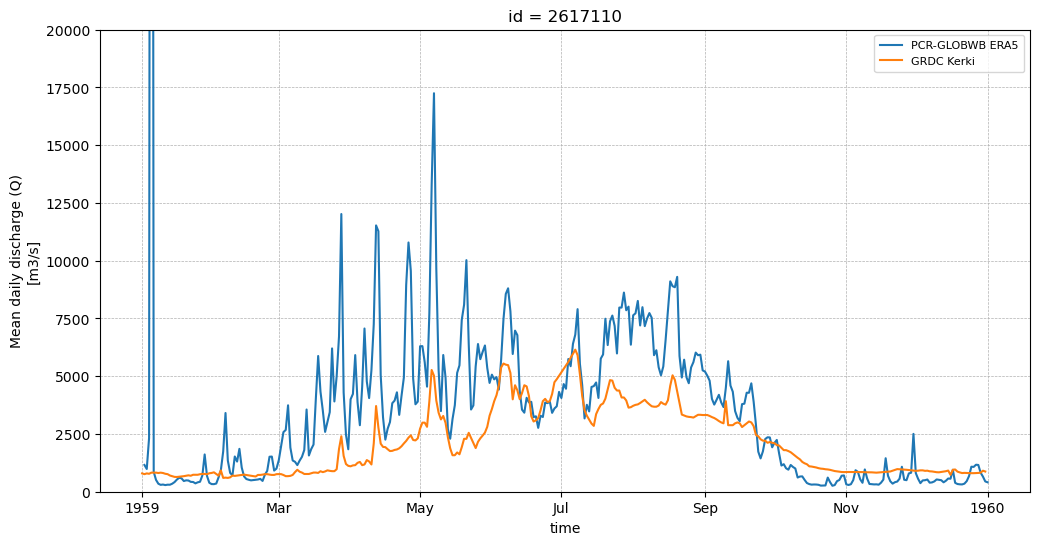

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(Stations_timeseries["Kerki"], label="PCR-GLOBWB ERA5")
grdc_kerki["streamflow"].sel(time=slice("1959", "1959")).plot(label="GRDC Kerki")
plt.legend(fontsize=8, markerscale=0.8, frameon=True, borderpad=0.5)
plt.ylim(0, 20000)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

## make map

In [42]:
ds = xr.open_dataset(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_shapefile/pcrglobwb_20251217_123110/netcdf/discharge_dailyTot_output.nc"
)

In [43]:
ds

<xarray.Dataset> Size: 66MB
Dimensions:    (time: 366, lat: 180, lon: 252)
Coordinates:
  * time       (time) datetime64[ns] 3kB 1959-01-01 1959-01-02 ... 1960-01-01
  * lat        (lat) float32 720B 48.96 48.88 48.79 48.71 ... 34.21 34.12 34.04
  * lon        (lon) float32 1kB 59.04 59.12 59.21 59.29 ... 79.79 79.88 79.96
Data variables:
    discharge  (time, lat, lon) float32 66MB ...
Attributes:
    description:  by Edwin H. Sutanudjaja (contact: e.h.sutanudjaja@uu.nl)
    institution:  Department of Physical Geography, Utrecht University
    title:        PCR-GLOBWB 2 output (not coupled to MODFLOW)

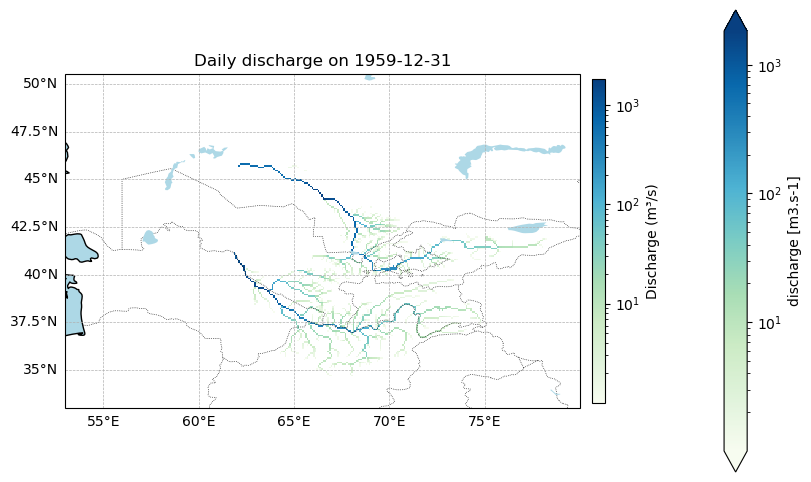

In [ ]:
# Your subset
subset = ds["discharge"].isel(
    time=-2  # Select a specific time if applicable
)

# pick an existing time from your dataset

subset = subset.where(subset > 1)

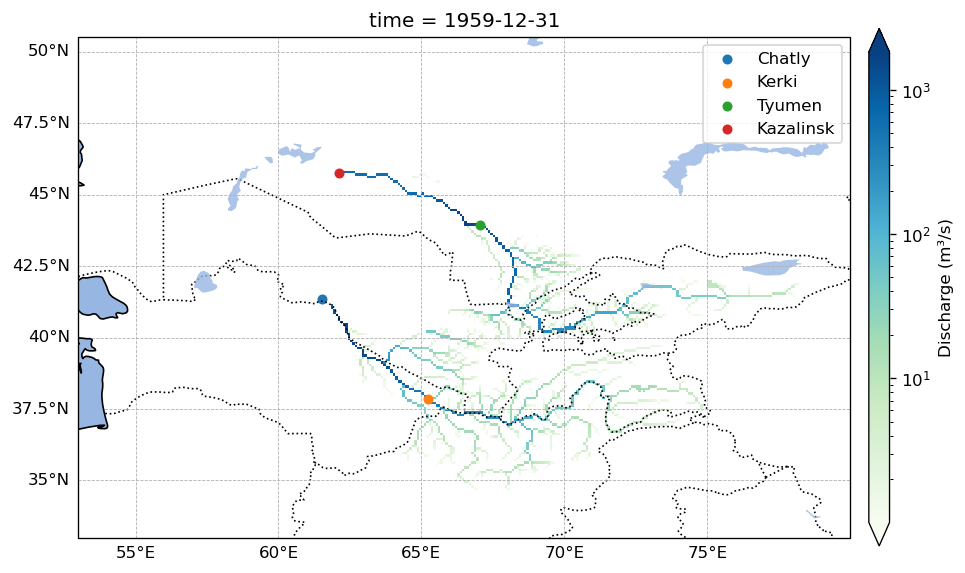

In [69]:
# Create figure
fig = plt.figure(figsize=(10, 8), dpi=120)
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

# Plot discharge with log scale and capture the QuadMesh (mappable)
mappable = subset.plot(
    ax=ax,
    cmap="GnBu",
    norm=LogNorm(vmin=subset.min(), vmax=subset.max()),
    add_colorbar=False,  # prevent xarray from adding a default colorbar
)

# Add colorbar manually
cbar = fig.colorbar(
    mappable,  # <-- THIS is the QuadMesh returned by plot()
    ax=ax,
    orientation="vertical",
    shrink=0.7,
    aspect=25,
    pad=0.02,
    extend="both",
)
cbar.set_label("Discharge (m³/s)")

# Plot stations
ax.scatter(
    Chatly_station_longitude + 1, Chatly_station_latitude - 0.5, s=25, c="tab:blue", label="Chatly"
)
ax.scatter(Kerki_station_longitude, Kerki_station_latitude, s=25, c="tab:orange", label="Kerki")
ax.scatter(Tyumen_station_longitude, Tyumen_station_latitude, s=25, c="tab:green", label="Tyumen")
ax.scatter(
    Kazalinsk_station_longitude, Kazalinsk_station_latitude, s=25, c="tab:red", label="Kazalinsk"
)

# Coastlines and other features
ax.add_feature(cfeature.OCEAN, zorder=2)
ax.add_feature(cfeature.BORDERS, linestyle=":", zorder=2)
ax.add_feature(cfeature.LAKES, alpha=0.8, zorder=2)
ax.coastlines(zorder=3)

# Set map extent
ax.set_extent([53, 80, 33, 50])

gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5)
gl.top_labels = False
gl.right_labels = False


# Legend
ax.legend(loc="upper right")

plt.show()